# 01 — Exploratory Data Analysis

Run `python -m src.build_dataset` first to generate `data/processed/`.
Visualizes label imbalance, label cardinality, stratification quality, and the top unmapped GoodScents descriptors.

In [1]:
import sys
sys.path.append('..')
import json
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import path

proc, inter, figs = path('data_processed'), path('data_interim'), path('reports_figures')
labels = json.loads((proc / 'label_names.json').read_text())
Ytr = sp.load_npz(proc / 'Y_train.npz').toarray()
Yte = sp.load_npz(proc / 'Y_test.npz').toarray()
Y = np.vstack([Ytr, Yte])
summary = json.loads((proc / 'dataset_summary.json').read_text())
summary

{'seed': 42,
 'fingerprint': {'radius': 2, 'n_bits': 2048, 'preserve_stereo': True},
 'n_records_raw': 12311,
 'n_unique_canonical': 7194,
 'n_smiles_parse_fail': 61,
 'n_labels_taxonomy': 114,
 'n_labels_kept': 111,
 'min_positive_count': 30,
 'n_train': 5569,
 'n_test': 1467,
 'x_n_features': 2048,
 'train_test_disjoint': True,
 'train_positives_per_label': {'alcoholic': 94,
  'aldehydic': 147,
  'alliaceous': 114,
  'almond': 110,
  'animal': 170,
  'anisic': 90,
  'apple': 387,
  'apricot': 118,
  'aromatic': 76,
  'balsamic': 474,
  'banana': 163,
  'beefy': 34,
  'berry': 230,
  'brandy': 48,
  'brothy': 32,
  'burnt': 162,
  'buttery': 154,
  'cabbage': 49,
  'camphoreous': 143,
  'caramellic': 231,
  'chamomile': 30,
  'cheesy': 181,
  'cherry': 110,
  'chicken': 44,
  'chocolate': 98,
  'cinnamon': 68,
  'citrus': 486,
  'cocoa': 116,
  'coconut': 127,
  'coffee': 126,
  'cognac': 99,
  'coumarinic': 61,
  'creamy': 234,
  'cucumber': 62,
  'dairy': 109,
  'dry': 126,
  'earth

## Label frequency (class imbalance)

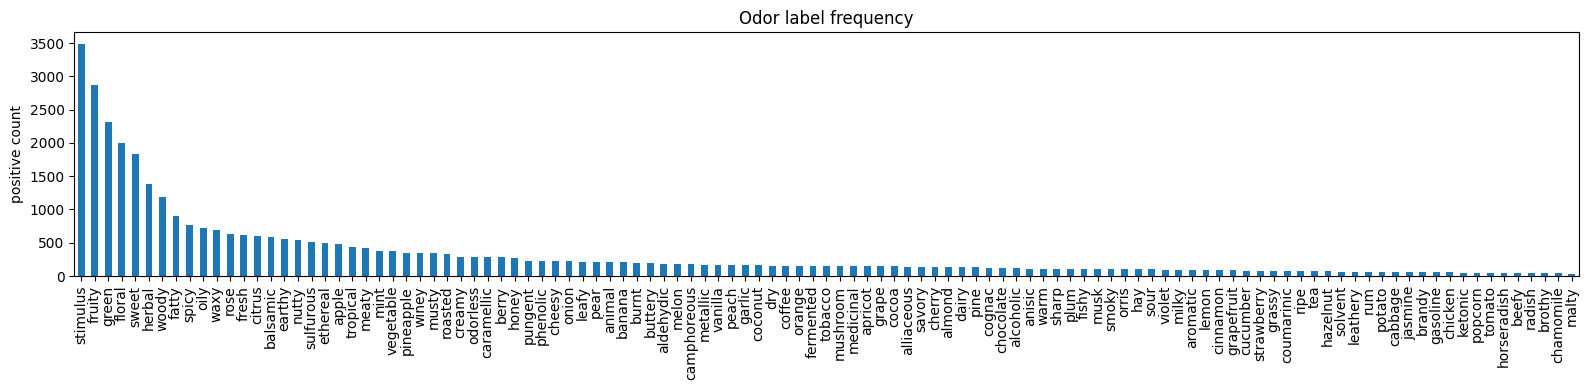

count     111.000000
mean      332.135135
std       541.857185
min        35.000000
25%        90.500000
50%       156.000000
75%       310.000000
max      3487.000000
dtype: float64

In [2]:
freq = pd.Series(Y.sum(0), index=labels).sort_values(ascending=False)
ax = freq.plot(kind='bar', figsize=(16, 4))
ax.set_ylabel('positive count'); ax.set_title('Odor label frequency')
plt.tight_layout(); plt.savefig(figs / 'label_frequency.png', dpi=150); plt.show()
freq.describe()

## Label cardinality (labels per molecule)

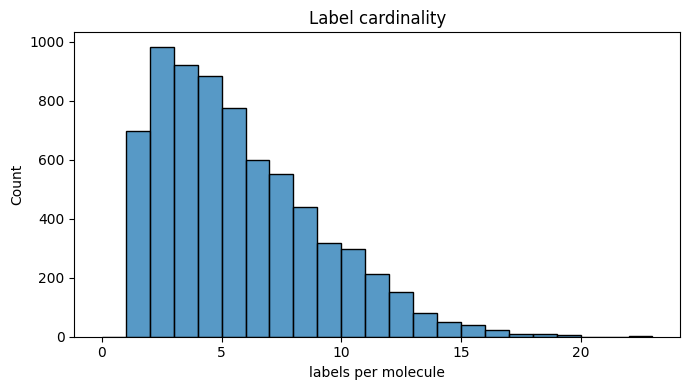

mean labels/molecule: 5.24


In [3]:
card = Y.sum(1)
plt.figure(figsize=(7, 4))
sns.histplot(card, bins=range(0, int(card.max()) + 2))
plt.xlabel('labels per molecule'); plt.title('Label cardinality')
plt.tight_layout(); plt.savefig(figs / 'label_cardinality.png', dpi=150); plt.show()
print('mean labels/molecule:', round(float(card.mean()), 3))

## Stratification check: train vs test positive rate per label

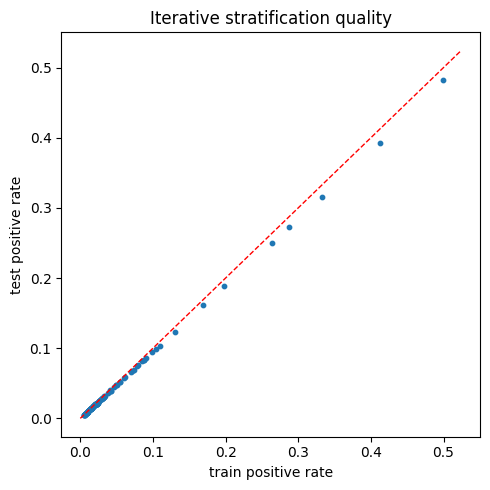

In [4]:
rate = pd.DataFrame({'train': Ytr.mean(0), 'test': Yte.mean(0)}, index=labels)
plt.figure(figsize=(5, 5))
plt.scatter(rate['train'], rate['test'], s=10)
lim = float(rate.values.max()) * 1.05
plt.plot([0, lim], [0, lim], 'r--', lw=1)
plt.xlabel('train positive rate'); plt.ylabel('test positive rate')
plt.title('Iterative stratification quality'); plt.tight_layout()
plt.savefig(figs / 'stratification_check.png', dpi=150); plt.show()

## Top unmapped GoodScents descriptors (extend SYNONYMS for these)

In [5]:
um = pd.read_csv(inter / 'unmapped_descriptors.csv')
um.head(30)

,descriptor,count
0,powdery,186
1,jasmin,148
2,camphoraceous,119
3,musky,106
4,hyacinth,103
5,geranium,95
6,clean,92
7,bland,90
8,lily,86
9,amber,85
